# **Library**

In [ ]:
import pandas as pd
import random
import numpy as np
import torch
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# untuk augmentasi
import re
from transformers import pipeline
from sentence_transformers import SentenceTransformer, util

# model indobertweet
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW # Import AdamW dari torch.optim
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.nn import CrossEntropyLoss

# model lstm
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# model ml ekstraksi fitur
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.')
else:
    device = torch.device("cpu")
    print('Tidak ada GPU yang tersedia. Menggunakan CPU untuk pelatihan.')

Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.


Set Seed for Reproducibility

In [ ]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)
print("Seed telah diatur untuk reproduktibilitas.")

Seed telah diatur untuk reproduktibilitas.


**Konfigurasi**

In [ ]:
# Dataset Ori
FILE_ID = '1zCIipCHY3xvFtgGeFBMLWATXsY96czdi'
INPUT_FILE = 'Slowliving_Label.csv'

# Dataset Aug
OUTPUT_FILE = 'Slowliving_sinonimreplacement.csv'

MODEL_NAME = 'xlm-roberta-large'
NUM_VARIATIONS = 7
SCORE_THRESHOLD = 0.05
SEMANTIC_THRESHOLD = 0.3
TARGET_AUG_PER_LABEL = {'netral': 900, 'negatif': 1000}

# **Load Dataset**

In [ ]:
gdown.download(id=FILE_ID, output=INPUT_FILE, quiet=False)
df = pd.read_csv(INPUT_FILE)
display(df.head(1))
df.info()

Downloading...
From: https://drive.google.com/uc?id=1zCIipCHY3xvFtgGeFBMLWATXsY96czdi
To: /content/Slowliving_Label.csv
100%|██████████| 1.02M/1.02M [00:00<00:00, 107MB/s]


,full_text,sentiment,slang,stemming,label
0,bulan di batam ngajarin aku kalo menyesuaikan ...,positif,bulan di batam ngajarin saya kalo menyesuaik...,bulan di batam ngajarin saya kalo sesuai phase...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3417 non-null   object
 1   sentiment  3417 non-null   object
 2   slang      3417 non-null   object
 3   stemming   3417 non-null   object
 4   label      3417 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 133.6+ KB


# **EDA**

/tmp/ipython-input-4118028567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


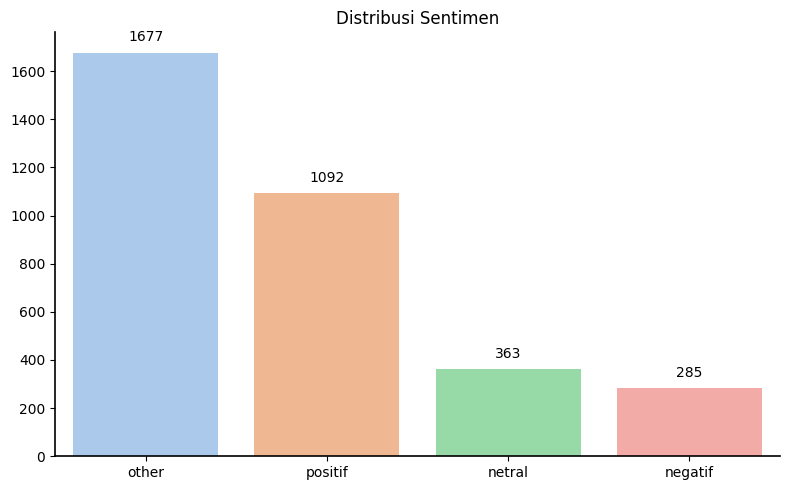

In [ ]:
# Mapping label ke nama sentimen
label_to_sentiment = {0: 'netral', 1: 'positif', 2: 'negatif', 3: 'other'}
df['sentiment'] = df['label'].map(label_to_sentiment)

# Hitung jumlah per sentimen
label_counts = df['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Sentimen')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

==== Prepare Data ====

In [ ]:
df = df[['sentiment', 'stemming', 'label']]
print("\n✅ Dataset dimuat. Contoh:")
display(df.head(2))
df.info()


✅ Dataset dimuat. Contoh:


,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  3417 non-null   object
 1   stemming   3417 non-null   object
 2   label      3417 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 80.2+ KB


# **Split Data**

70 15 15

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['stemming'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

In [ ]:
# df_train menampung hasil dari xtrain
df_train = pd.DataFrame({'stemming': train_texts, 'label': train_labels})

# Tambahkan kolom 'sentiment' ke df_train dengan memetakan 'label' ke 'sentiment' dari dataframe df/utama
label_to_sentiment = df.set_index('label')['sentiment'].to_dict()
df_train['sentiment'] = df_train['label'].map(label_to_sentiment)

print(f"\n📊 Jumlah data train: {len(df_train)} | val: {len(val_texts)} | test: {len(test_texts)}")
display(df_train.head(2))
df_train.info()


📊 Jumlah data train: 2391 | val: 513 | test: 513


,stemming,label,sentiment
3163,pen jadi pegawai negeri sipil pemkot slow livi...,1,positif
1941,panas banget hari minum es tentu sangat enak,3,other


<class 'pandas.core.frame.DataFrame'>
Index: 2391 entries, 3163 to 1100
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   stemming   2391 non-null   object
 1   label      2391 non-null   int64 
 2   sentiment  2391 non-null   object
dtypes: int64(1), object(2)
memory usage: 74.7+ KB


/tmp/ipython-input-3125339172.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


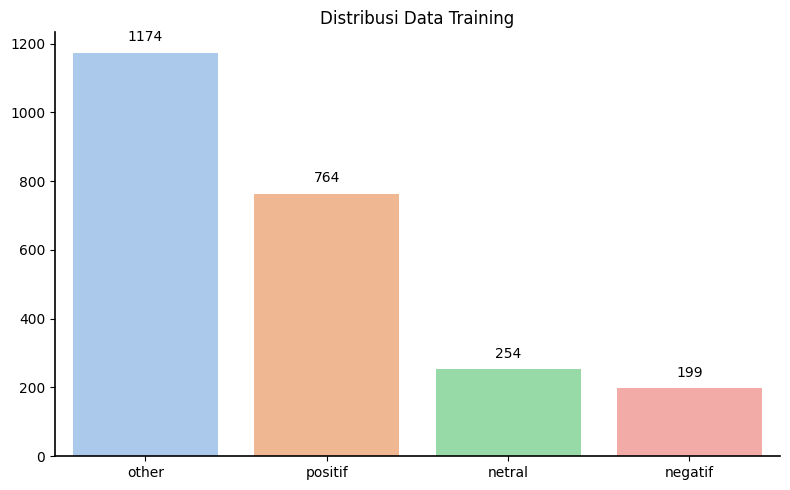

In [ ]:
df_train['sentiment'] = df_train['label'].map(label_to_sentiment)

# Hitung jumlah sentimen
label_counts = df_train['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **Teknik Augmentasi Synonym Replacement**

In [ ]:
# ====== Inisialisasi Model Masking & Semantic ======
device = 0 if torch.cuda.is_available() else -1
unmasker = pipeline('fill-mask', model=MODEL_NAME, tokenizer=MODEL_NAME, device=device)
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at xlm-roberta-large were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# ====== Stopwords & Utility ======
# Daftar Kata-kata ini diabaikan agar tidak diganti
STOPWORDS = {
    'slow', 'living', 'life', 'mindfulness', 'hustle', 'culture', 'meaningful',
    'slowly', 'style', 'minimalism', 'pace', 'weekend', 'frugal', 'fast',
    'yang', 'untuk', 'dan', 'ini', 'km', 'aku'  # Contoh stopwords bahasa Indonesia
}

# Fungsi untuk masking kata
def safe_mask(text, word):
    return re.sub(rf'\b{re.escape(word)}\b', '<mask>', text, count=1)

# ---
# ## Fungsi Augmentasi Utama

def augment_synonym_xlmr(text, unmasker, semantic_model, num_variations, score_threshold, semantic_threshold):
    """
    Melakukan augmentasi synonym replacement pada satu kalimat.

    Menggunakan model fill-mask untuk mendapatkan kandidat, lalu memfilter
    dengan model Sentence-Transformer untuk memastikan kemiripan semantik.
    """
    words = [w for w in text.split() if w.isalpha() and len(w) > 3 and w.lower() not in STOPWORDS]
    random.shuffle(words)

    augmented_texts = []

    for word in words:
        if len(augmented_texts) >= num_variations:
            break

        masked_text = safe_mask(text, word)
        if '<mask>' not in masked_text:
            continue

        try:
            predictions = unmasker(masked_text, top_k=10) # Ambil lebih banyak kandidat
        except Exception as e:
            print(f"[WARN] Masking error for '{word}': {e}")
            continue

        for pred in predictions:
            token = pred['token_str'].strip()
            score = pred['score']

            # Cek jika kandidat valid (bukan kata yang sama, bukan angka, dan skor di atas threshold)
            if token.lower() != word.lower() and score >= score_threshold and token.isalpha():

                # --- Filter semantik ---
                # Hitung kesamaan kosinus antara kata asli dan kandidat
                embeddings = semantic_model.encode([word, token], convert_to_tensor=True)
                cosine_similarity = util.cos_sim(embeddings[0], embeddings[1]).item()

                if cosine_similarity >= semantic_threshold:
                    new_text = masked_text.replace('<mask>', token, 1)
                    augmented_texts.append(new_text.lower())
                    print(f"[DEBUG] '{word}' diganti menjadi '{token}' (Sim: {cosine_similarity:.2f}) ➝ {new_text}")
                    break  # Pindah ke kata berikutnya untuk variasi lain

    return augmented_texts

In [ ]:
augmented_data = []

for label, target_count in TARGET_AUG_PER_LABEL.items():
    label_subset = df[df['sentiment'] == label][['stemming']]
    current_count = 0

    print(f"\n🔄 Memulai augmentasi untuk label '{label}'...")

    for _, row in label_subset.iterrows():
        if current_count >= target_count:
            break

        text = str(row['stemming']) # Pastikan teks berupa string

        # Panggil fungsi augmentasi yang telah direfaktor
        results = augment_synonym_xlmr(
            text,
            unmasker,
            semantic_model,
            num_variations=NUM_VARIATIONS,
            score_threshold=SCORE_THRESHOLD,
            semantic_threshold=SEMANTIC_THRESHOLD
        )

        if results:
            results = results[:target_count - current_count]
            for result_text in results:
                augmented_data.append({'stemming': result_text, 'sentiment': label})
            current_count += len(results)

    print(f"✅ Augmentasi label '{label}' selesai. Total: {current_count} data.")


🔄 Memulai augmentasi untuk label 'netral'...
[DEBUG] 'sekali' diganti menjadi 'suka' (Sim: 0.45) ➝ suka sekali slow living
[DEBUG] 'sekali' diganti menjadi 'suka' (Sim: 0.45) ➝ suka sekali slow living
[DEBUG] 'biar' diganti menjadi 'agar' (Sim: 0.55) ➝ planning slow living kereta rel listrik transit telat paksa deh naik ojek agar tidak lambat presensi
[DEBUG] 'ojek' diganti menjadi 'kereta' (Sim: 0.32) ➝ planning slow living kereta rel listrik transit telat paksa deh naik kereta biar tidak lambat presensi
[DEBUG] 'lambat' diganti menjadi 'ketinggalan' (Sim: 0.40) ➝ planning slow living kereta rel listrik transit telat paksa deh naik ojek biar tidak ketinggalan presensi


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[DEBUG] 'tidak' diganti menjadi 'tak' (Sim: 0.33) ➝ planning slow living kereta rel listrik transit telat paksa deh naik ojek biar tak lambat presensi
[DEBUG] 'bukan' diganti menjadi 'untuk' (Sim: 0.36) ➝ slow living seni tahan hidup di zaman serba cepat tak apa untuk gerak perlahan hidup untuk saat sekarang untuk esok kemarin laku baik bisa kau laku hari tak perlu buru buru takut tinggal oleh apa
[DEBUG] 'laku' diganti menjadi 'lebih' (Sim: 0.40) ➝ slow living seni tahan hidup di zaman serba cepat tak apa untuk gerak perlahan hidup untuk saat sekarang bukan esok kemarin lebih baik bisa kau laku hari tak perlu buru buru takut tinggal oleh apa
[DEBUG] 'baik' diganti menjadi 'yang' (Sim: 0.38) ➝ slow living seni tahan hidup di zaman serba cepat tak apa untuk gerak perlahan hidup untuk saat sekarang bukan esok kemarin laku yang bisa kau laku hari tak perlu buru buru takut tinggal oleh apa
[DEBUG] 'esok' diganti menjadi 'untuk' (Sim: 0.35) ➝ slow living seni tahan hidup di zaman serba cepa

In [ ]:
# ====== Simpan dan Statistik ======
df_aug = pd.DataFrame(augmented_data)
df_aug.to_csv(OUTPUT_FILE, index=False)

print("\n📦 Augmentasi selesai:")
print(f"- Data training sebelum augmentasi: {len(df_train)}")
print(f"- Data hasil augmentasi           : {len(df_aug)}")
print(f"- File disimpan sebagai           : {OUTPUT_FILE}")


📦 Augmentasi selesai:
- Data training sebelum augmentasi: 2391
- Data hasil augmentasi           : 1900
- File disimpan sebagai           : Slowliving_sinonimreplacement.csv


# **Encoding**

Penanganan duplikat dan encoding hasil augmentasi

In [ ]:
# Hapus duplikat berdasarkan kolom 'stemming'
df_aug = df_aug.drop_duplicates(subset='stemming', keep='first')


# Encode label
sentiment_to_label = {
    'netral': 0,
    'positif': 1,
    'negatif': 2,
    'other': 3
}

# Gunakan mapping ini untuk hasil augmentasi
df_aug['label'] = df_aug['sentiment'].map(sentiment_to_label)

# Tampilkan informasi dan contoh data
display(df_aug.head(2))
df_aug.info()


,stemming,sentiment,label
0,suka sekali slow living,netral,0
2,planning slow living kereta rel listrik transi...,netral,0


<class 'pandas.core.frame.DataFrame'>
Index: 1824 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   stemming   1824 non-null   object
 1   sentiment  1824 non-null   object
 2   label      1824 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 57.0+ KB


Penggabungan data train dan data hasil aug

In [ ]:
df_train_augmented = pd.concat([df_train[['stemming', 'label']], df_aug[['stemming', 'label']]], ignore_index=True)
print(f"\n📊 Total data training setelah augmentasi: {len(df_train_augmented)}")
display(df_train_augmented.head(2))
df_train_augmented.info()


📊 Total data training setelah augmentasi: 4215


,stemming,label
0,pen jadi pegawai negeri sipil pemkot slow livi...,1
1,panas banget hari minum es tentu sangat enak,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4215 entries, 0 to 4214
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   stemming  4215 non-null   object
 1   label     4215 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 66.0+ KB


/tmp/ipython-input-3432596017.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


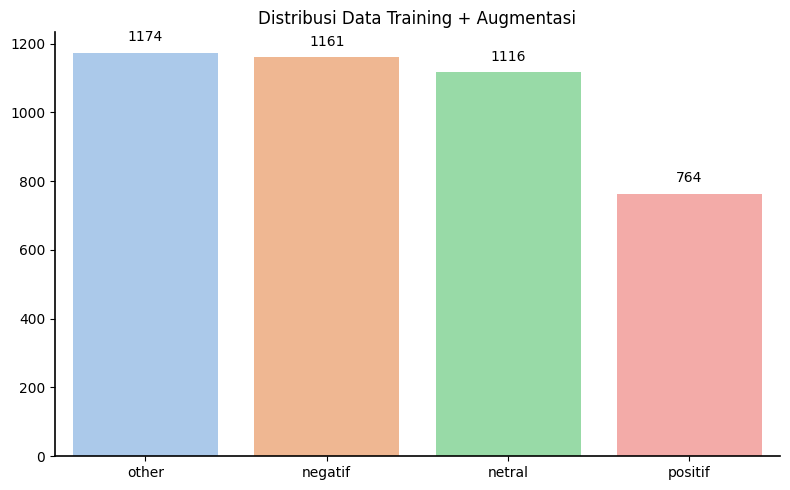

In [ ]:
df_train_augmented['sentiment'] = df_train_augmented['label'].map(label_to_sentiment)

# Hitung jumlah sentimen
label_counts = df_train_augmented['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training + Augmentasi')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **Model IndoBERTweet**

### **Tokenize Data Loader**

In [ ]:
# Menginisialisasi tokenizer IndoBERTweet
print("\nMenginisialisasi tokenizer IndoBERTweet...")
tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')

# Fungsi untuk tokenisasi dan encoding data
def encode_data(tokenizer, texts, labels):
    input_ids = []
    attention_masks = []
    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=128,  # Menetapkan panjang maksimum sequence
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels)
    return TensorDataset(input_ids, attention_masks, labels)

# Menerapkan fungsi encoding ke setiap set data
train_dataset = encode_data(tokenizer, df_train_augmented['stemming'].tolist(), df_train_augmented['label'].tolist())
val_dataset = encode_data(tokenizer, val_texts.tolist(), val_labels.tolist())
test_dataset = encode_data(tokenizer, test_texts.tolist(), test_labels.tolist())

# Membuat DataLoader untuk memproses data dalam batch
batch_size = 16
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)


Menginisialisasi tokenizer IndoBERTweet...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### **Load Model**

In [ ]:
num_labels = 4
model = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobertweet-base-uncased',
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# Mengatur optimizer dan scheduler dengan learning rate dan epsilon yang ditentukan
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 4
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### **Training**

In [ ]:
print("\n--- Memulai Pelatihan ---")
# Menyimpan riwayat metrik untuk visualisasi
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience = 1
patience_counter = 0
best_model_state = None

for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")

    # Mode pelatihan (training)
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    for step, batch in enumerate(train_dataloader):
        if step % 50 == 0 and not step == 0:
            print(f'  Batch {step} dari {len(train_dataloader)}.')

        # Memindahkan batch data ke device (GPU/CPU)
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        total_train_loss += loss.item()

        # Menghitung akurasi batch
        preds = torch.argmax(logits, dim=1)
        total_train_accuracy += (preds == b_labels).sum().item() / len(b_labels)

        loss.backward() # Propagasi balik
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Mencegah exploding gradients
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_accuracy / len(train_dataloader)

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)

    print(f"  Rata-rata loss pelatihan: {avg_train_loss:.2f}")
    print(f"  Rata-rata akurasi pelatihan: {avg_train_acc:.2f}")

    # Mode evaluasi (validation)
    model.eval()
    total_eval_loss = 0
    total_eval_accuracy = 0

    for batch in val_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        logits = outputs.logits
        total_eval_loss += loss.item()

        # Menghitung akurasi validasi
        preds = torch.argmax(logits, dim=1)
        total_eval_accuracy += (preds == b_labels).sum().item() / len(b_labels)

    avg_val_loss = total_eval_loss / len(val_dataloader)
    avg_val_acc = total_eval_accuracy / len(val_dataloader)

    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)

    print(f"  Rata-rata loss validasi: {avg_val_loss:.2f}")
    print(f"  Rata-rata akurasi validasi: {avg_val_acc:.2f}")

    # Implementasi Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("  Loss validasi menurun. Menyimpan model terbaik.")
    else:
        patience_counter += 1
        print(f"  Loss validasi tidak menurun. Patience counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"  Early stopping! Pelatihan dihentikan setelah {epoch_i + 1} epoch.")
            break

# Muat kembali model terbaik yang telah disimpan
if best_model_state is not None:
    model.load_state_dict(best_model_state)


--- Memulai Pelatihan ---

======== Epoch 1 / 4 ========


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

  Batch 50 dari 264.
  Batch 100 dari 264.
  Batch 150 dari 264.
  Batch 200 dari 264.
  Batch 250 dari 264.
  Rata-rata loss pelatihan: 0.88
  Rata-rata akurasi pelatihan: 0.65
  Rata-rata loss validasi: 0.50
  Rata-rata akurasi validasi: 0.80
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 2 / 4 ========
  Batch 50 dari 264.
  Batch 100 dari 264.
  Batch 150 dari 264.
  Batch 200 dari 264.
  Batch 250 dari 264.
  Rata-rata loss pelatihan: 0.41
  Rata-rata akurasi pelatihan: 0.85
  Rata-rata loss validasi: 0.39
  Rata-rata akurasi validasi: 0.85
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 3 / 4 ========
  Batch 50 dari 264.
  Batch 100 dari 264.
  Batch 150 dari 264.
  Batch 200 dari 264.
  Batch 250 dari 264.
  Rata-rata loss pelatihan: 0.23
  Rata-rata akurasi pelatihan: 0.92
  Rata-rata loss validasi: 0.34
  Rata-rata akurasi validasi: 0.89
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 4 / 4 ========
  Batch 50 dari 264.
 

apikey a5153cecda5fef1b45867e96aa08c5cc24f8771a

### **Evaluasi Model**


Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68        55
           1       0.87      0.88      0.88       164
           2       0.75      0.84      0.79        43
           3       0.98      0.97      0.98       251

    accuracy                           0.90       513
   macro avg       0.83      0.84      0.83       513
weighted avg       0.90      0.90      0.90       513



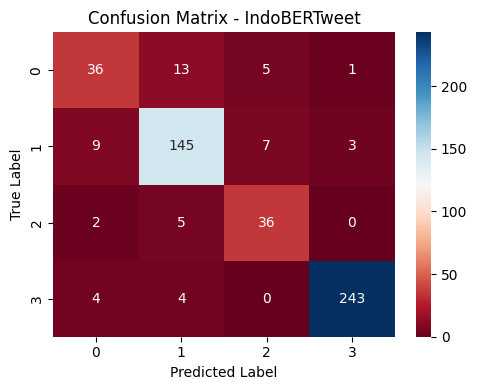

Akurasi model pada data pengujian: 0.8967


In [ ]:
model.eval()

predictions, true_labels = [], []
for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    predictions.extend(np.argmax(logits, axis=1).flatten())
    true_labels.extend(label_ids.flatten())

print("\nLaporan Klasifikasi:")
# Laporan yang mencakup Precision, Recall, dan F1-score
print(classification_report(true_labels, predictions))

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=range(model.config.num_labels),
            yticklabels=range(model.config.num_labels))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - IndoBERTweet")
plt.tight_layout()
plt.show()

test_accuracy = accuracy_score(true_labels, predictions)
print(f"Akurasi model pada data pengujian: {test_accuracy:.4f}")

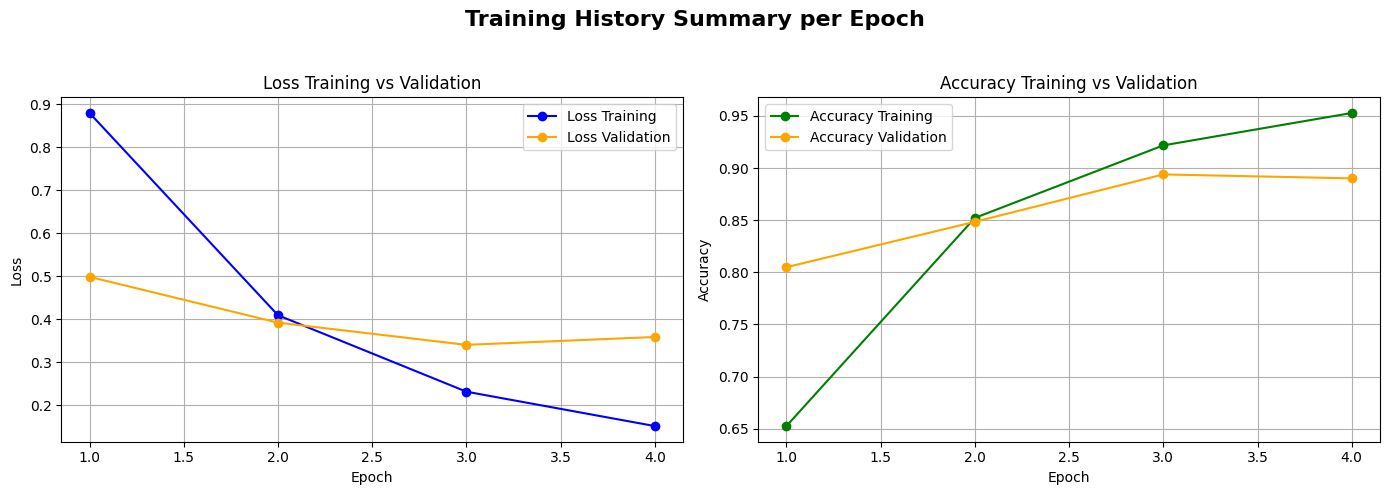

In [ ]:
epochs_run = len(history['train_loss'])
epochs_range = range(1, epochs_run + 1)

# Buat 1 baris, 2 kolom plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Loss ===
ax1.plot(epochs_range, history['train_loss'], label='Loss Training', color='blue', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Loss Validation', color='orange', marker='o')
ax1.set_title('Loss Training vs Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# === Plot 2: Accuracy ===
ax2.plot(epochs_range, history['train_acc'], label='Accuracy Training', color='green', marker='o')
ax2.plot(epochs_range, history['val_acc'], label='Accuracy Validation', color='orange', marker='o')
ax2.set_title('Accuracy Training vs Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Judul
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Error Analisis**

In [ ]:
print("\n--- Analisis Sampel Teks yang Salah Diklasifikasikan ---")

# Konversi true_labels dan predictions menjadi array numpy untuk perbandingan
true_labels_np = np.array(true_labels)
predictions_np = np.array(predictions)

# Mencari indeks di mana true_labels tidak sama dengan predictions
misclassified_indices = np.where(true_labels_np != predictions_np)[0]

print(f"Total sampel yang salah diklasifikasikan: {len(misclassified_indices)}")

# Reverse the label mapping to get sentiment strings from labels
label_to_sentiment = {v: k for k, v in sentiment_to_label.items()}

# Creating DataFrame for error analysis
misclassified_data = {
    'Teks': [test_texts.iloc[i] for i in misclassified_indices], # Use iloc for positional indexing
    'True Label (Sentiment)': [label_to_sentiment[true_labels_np[i]] for i in misclassified_indices], # Map label to sentiment
    'Predicted Label (Sentiment)': [label_to_sentiment[predictions_np[i]] for i in misclassified_indices] # Map label to sentiment
}
misclassified_df = pd.DataFrame(misclassified_data)

# Displaying all misclassified samples for further analysis
print("\nMenampilkan semua sampel teks yang salah diklasifikasikan:")
display(misclassified_df.head(50))


--- Analisis Sampel Teks yang Salah Diklasifikasikan ---
Total sampel yang salah diklasifikasikan: 53

Menampilkan semua sampel teks yang salah diklasifikasikan:


,Teks,True Label (Sentiment),Predicted Label (Sentiment)
0,slow living bukan tidak produktif malah lebih ...,netral,negatif
1,slow living kalo tidak livingnya sama kamu bua...,netral,negatif
2,sini rasa slow living banget help lebih tidak ...,negatif,positif
3,jakarta in general juga slow life trafficnya slow,netral,other
4,slow living itu tinggal di kabupaten enggaaaaa...,negatif,netral
5,tiap banyak kerja inget ngetuit tapi gi slow l...,netral,negatif
6,tapi sini klo misal pacar p zee dya akan coba ...,other,netral
7,memang slow living di klaten tidak ganti,positif,negatif
8,sini tidak ada daily tweets adminnya mageran s...,positif,netral
9,saya pikir lama saya slow living banget yaaa k...,netral,positif


In [ ]:
misclassified_df.to_csv('misclassified_sempel.csv', index=False)

# **Model LSTM**

Langsung lanjut ke deploy model sampai ke tahap evaluasi

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

## **Tokenize Padding**

In [ ]:
# Parameters for tokenization and padding
vocab_size = 10000  # Adjust based on your vocabulary size
max_length = 128    # Should be consistent with the BERT model's max_length
embedding_dim = 100 # Dimension of the word embeddings

# Initialize and fit the tokenizer on the training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train_augmented['stemming'])

# Convert texts to sequences of integers
train_sequences = tokenizer.texts_to_sequences(df_train_augmented['stemming'])
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Pad the sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Data preparation for LSTM complete.")
print("Shape of training data:", train_padded.shape)
print("Shape of validation data:", val_padded.shape)
print("Shape of test data:", test_padded.shape)

Data preparation for LSTM complete.
Shape of training data: (4215, 128)
Shape of validation data: (513, 128)
Shape of test data: (513, 128)


In [ ]:
# Calculate class weights to handle potential class imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_augmented['label']),
    y=df_train_augmented['label']
)

# Convert to dictionary format required by Keras model.fit
class_weights_dict = dict(enumerate(class_weights))

## **Deploy LSTM**

In [ ]:
# Define the LSTM model with the specified architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    # Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Dropout(0.3),
    Dense(len(np.unique(df_train_augmented['label'])), activation='softmax')
])

# Compile the model
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build and summarize the model
model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()

# Callback EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("\n--- Memulai Pelatihan LSTM ---")
history_lstm = model_lstm.fit(
    train_padded, df_train_augmented['label'], # Use the padded training data and augmented labels
    epochs=20,
    batch_size=16,
    validation_data=(val_padded, val_labels), # Use the padded validation data and validation labels
    class_weight=class_weights_dict, # Use the calculated class weights dictionary
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,452 (3.98 MB)

 Trainable params: 1,044,452 (3.98 MB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Pelatihan LSTM ---
Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4241 - loss: 1.2547 - val_accuracy: 0.7115 - val_loss: 0.6628
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8175 - loss: 0.5507 - val_accuracy: 0.8187 - val_loss: 0.5334
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9261 - loss: 0.2538 - val_accuracy: 0.8031 - val_loss: 0.6204
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9533 - loss: 0.1670 - val_accuracy: 0.7895 - val_loss: 0.7191
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9764 - loss: 0.1071 - val_accuracy: 0.7739 - val_loss: 0.8441
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9828 - loss: 0.0782 - val_accuracy: 0.7992 - val_loss: 0.8344
Epoch 7/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9944 - loss: 0.0550 - val_accuracy: 0.7973 - val_loss: 0.8363
Epoch 7: early stopping
Restoring model weights from the end of the be

## **Evaluasi Model**


--- Evaluasi Model LSTM ---
Test Loss: 0.5612
Test Accuracy: 0.8148
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.38      0.49        55
           1       0.69      0.83      0.75       164
           2       0.60      0.63      0.61        43
           3       0.97      0.93      0.95       251

    accuracy                           0.81       513
   macro avg       0.74      0.69      0.70       513
weighted avg       0.82      0.81      0.81       513



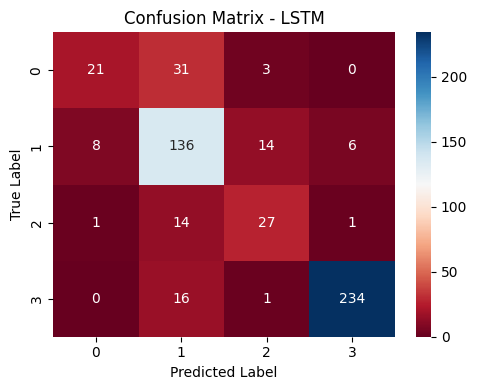

In [ ]:
# Evaluate the model on the test data
print("\n--- Evaluasi Model LSTM ---")
test_loss, test_acc = model_lstm.evaluate(test_padded, test_labels, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
y_pred = model_lstm.predict(test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_classes))

# Generate confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=np.unique(test_labels),  # Use unique labels from test set
            yticklabels=np.unique(test_labels))  # Use unique labels from test set
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.show()

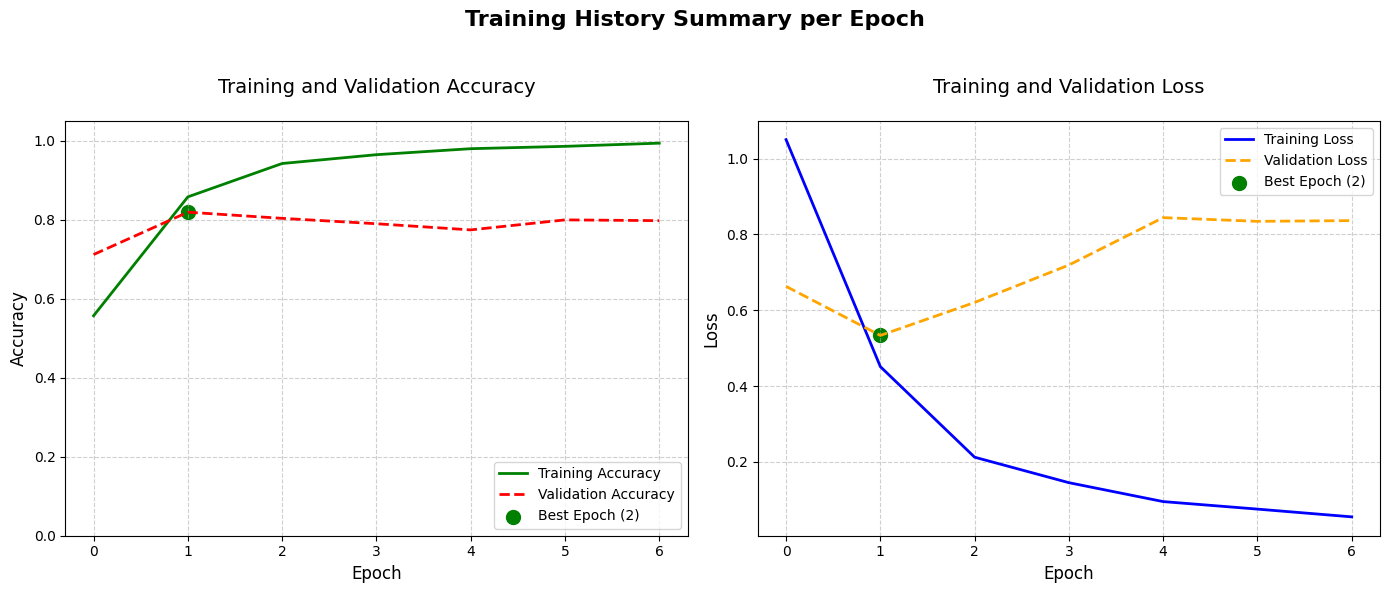

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get the number of epochs the model actually trained for
num_epochs = len(history_lstm.history['accuracy'])
epochs_range = range(num_epochs)

# Get the best epoch from the EarlyStopping callback
# If early stopping occurred, best_epoch is where performance was best
# If not, the last epoch is the best epoch in terms of performance on the monitored metric during training
if early_stop.stopped_epoch > 0:
    best_epoch = early_stop.best_epoch
else:
    best_epoch = num_epochs - 1 # If no early stopping, the last epoch is technically the "best" among the run epochs

# Plot Loss
axes[1].plot(epochs_range, history_lstm.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(epochs_range, history_lstm.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
axes[1].scatter(best_epoch, history_lstm.history['val_loss'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[1].set_title('Training and Validation Loss', fontsize=14, pad=20)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(epochs_range) # Set x-ticks to match the number of epochs

# Plot Accuracy
axes[0].plot(epochs_range, history_lstm.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[0].plot(epochs_range, history_lstm.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
axes[0].scatter(best_epoch, history_lstm.history['val_accuracy'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[0].set_title('Training and Validation Accuracy', fontsize=14, pad=20)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim([0, 1.05])  # Adjust y-axis limit for better visualization
axes[0].set_xticks(epochs_range) # Set x-ticks to match the number of epochs


# Atur layout dan spacing
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# **Model Machine Learning**

In [ ]:
print("Total training data:", df_train_augmented.shape[0])

Total training data: 4215


### **Ekstraksi Fitur**

Menggunakan BoW, TF-IDF dan N-Grams

In [ ]:
vectorizers_bow = {
    'BoW': CountVectorizer(max_features=5000),
}
vectorizers_tfidf = {
    'TFIDF': TfidfVectorizer(max_features=5000),
}
vectorizers_unigram = {
    'Unigram': CountVectorizer(max_features=5000, ngram_range=(1, 1)),
}
vectorizers_bigram = {
    'Bigram': CountVectorizer(max_features=5000, ngram_range=(2, 2)),
}
vectorizers_trigram = {
    'Trigram': CountVectorizer(max_features=5000, ngram_range=(3, 3)),
}

### **Evaluasi Model**

Konfigurasi Model ML

In [ ]:
# Inisialisasi model
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(C=1.0, solver='liblinear', class_weight='balanced',max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=40, min_samples_leaf=3, min_samples_split=2, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, min_samples_split=3, min_samples_leaf=3, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='linear', C=0.5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05, colsample_bytree=0.8, subsample=0.8, gamma=0.2, eval_metric='mlogloss', random_state=42),
}

In [ ]:
# Ambil data dari df_train_augmented
train_texts_for_ml = df_train_augmented['stemming']
train_labels_for_ml = df_train_augmented['label']

In [ ]:
train_texts_for_ml.shape[0]

4215

BoW


======== Vectorizer: BoW ========

Model: Naive Bayes
Test Accuracy: 0.7154
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.42      0.41        55
           1       0.69      0.72      0.71       164
           2       0.40      0.74      0.52        43
           3       0.95      0.77      0.85       251

    accuracy                           0.72       513
   macro avg       0.61      0.66      0.62       513
weighted avg       0.76      0.72      0.73       513



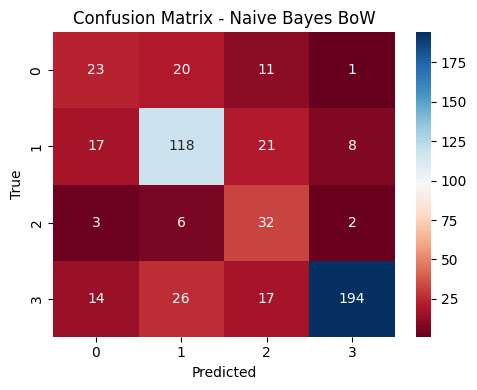


Model: Logistic Regression
Test Accuracy: 0.8168
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55        55
           1       0.79      0.73      0.76       164
           2       0.52      0.74      0.62        43
           3       0.97      0.94      0.96       251

    accuracy                           0.82       513
   macro avg       0.71      0.74      0.72       513
weighted avg       0.83      0.82      0.82       513



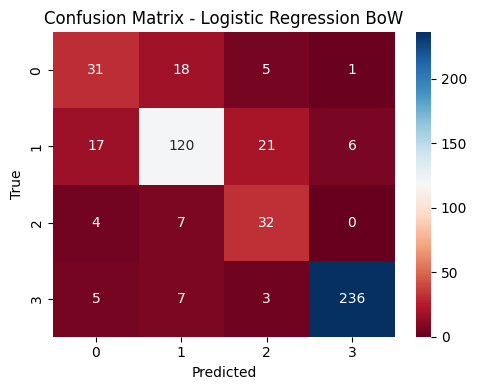


Model: Random Forest
Test Accuracy: 0.7641
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.25      0.36        55
           1       0.67      0.71      0.69       164
           2       0.39      0.49      0.43        43
           3       0.92      0.96      0.94       251

    accuracy                           0.76       513
   macro avg       0.65      0.60      0.60       513
weighted avg       0.76      0.76      0.75       513



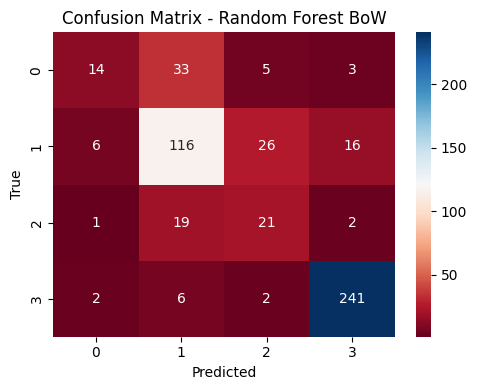


Model: Decision Tree
Test Accuracy: 0.7407
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.27      0.33        55
           1       0.62      0.72      0.67       164
           2       0.41      0.44      0.43        43
           3       0.95      0.91      0.93       251

    accuracy                           0.74       513
   macro avg       0.60      0.59      0.59       513
weighted avg       0.74      0.74      0.74       513



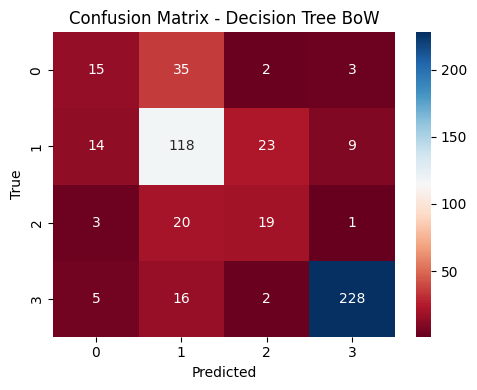


Model: SVM
Test Accuracy: 0.8148
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.58      0.57        55
           1       0.80      0.71      0.75       164
           2       0.54      0.74      0.63        43
           3       0.95      0.94      0.95       251

    accuracy                           0.81       513
   macro avg       0.71      0.75      0.72       513
weighted avg       0.82      0.81      0.82       513



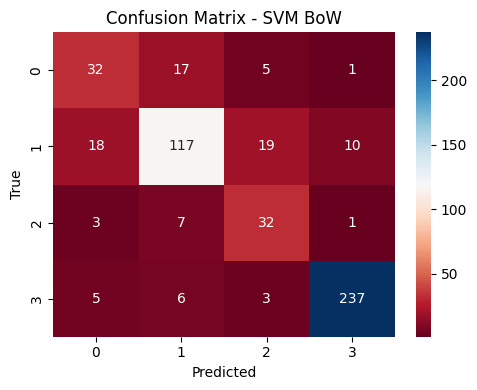


Model: XGBoost
Test Accuracy: 0.7739
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.44      0.46        55
           1       0.80      0.60      0.69       164
           2       0.42      0.81      0.55        43
           3       0.93      0.95      0.94       251

    accuracy                           0.77       513
   macro avg       0.66      0.70      0.66       513
weighted avg       0.80      0.77      0.78       513



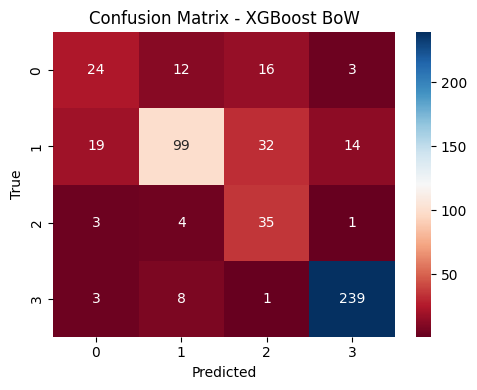

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bow.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts_for_ml)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels_for_ml)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


TF-IDF


======== Vectorizer: TFIDF ========

Model: Naive Bayes
Test Accuracy: 0.6608
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.53      0.42        55
           1       0.73      0.58      0.64       164
           2       0.36      0.77      0.49        43
           3       0.88      0.73      0.79       251

    accuracy                           0.66       513
   macro avg       0.58      0.65      0.59       513
weighted avg       0.73      0.66      0.68       513



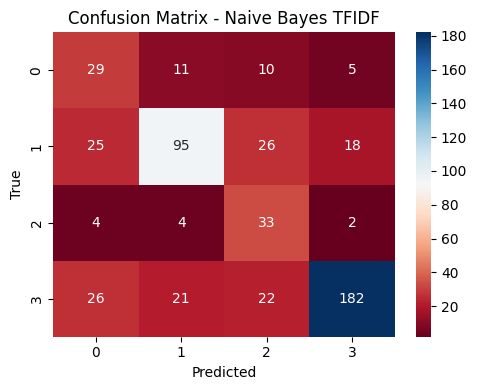


Model: Logistic Regression
Test Accuracy: 0.7953
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.55      0.55        55
           1       0.81      0.66      0.72       164
           2       0.46      0.74      0.57        43
           3       0.93      0.95      0.94       251

    accuracy                           0.80       513
   macro avg       0.69      0.72      0.70       513
weighted avg       0.81      0.80      0.80       513



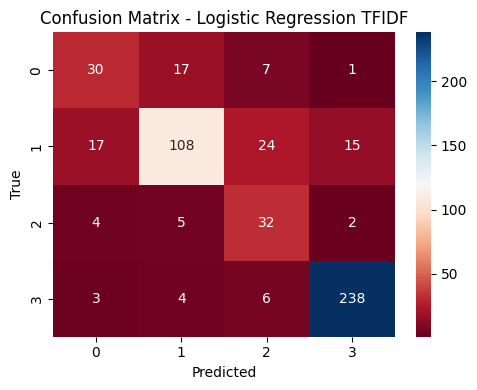


Model: Random Forest
Test Accuracy: 0.7602
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.27      0.37        55
           1       0.68      0.66      0.67       164
           2       0.40      0.58      0.47        43
           3       0.92      0.96      0.94       251

    accuracy                           0.76       513
   macro avg       0.64      0.62      0.61       513
weighted avg       0.76      0.76      0.75       513



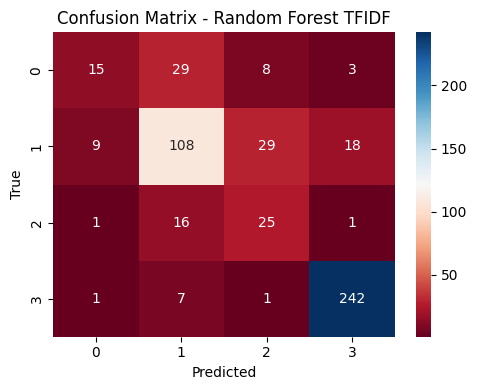


Model: Decision Tree
Test Accuracy: 0.7544
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.36      0.38        55
           1       0.70      0.67      0.69       164
           2       0.44      0.65      0.52        43
           3       0.95      0.91      0.93       251

    accuracy                           0.75       513
   macro avg       0.62      0.65      0.63       513
weighted avg       0.77      0.75      0.76       513



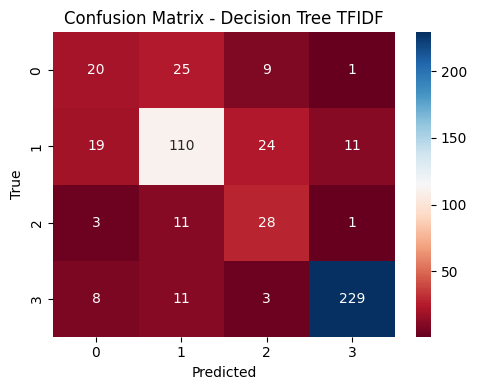


Model: SVM
Test Accuracy: 0.8109
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.51      0.54        55
           1       0.76      0.73      0.74       164
           2       0.55      0.72      0.63        43
           3       0.94      0.95      0.95       251

    accuracy                           0.81       513
   macro avg       0.71      0.73      0.71       513
weighted avg       0.81      0.81      0.81       513



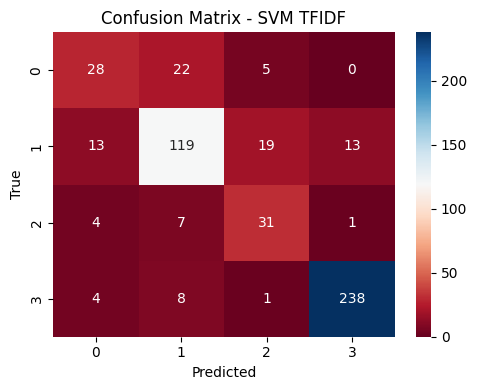


Model: XGBoost
Test Accuracy: 0.7505
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.49      0.47        55
           1       0.74      0.57      0.64       164
           2       0.39      0.72      0.51        43
           3       0.94      0.93      0.94       251

    accuracy                           0.75       513
   macro avg       0.63      0.68      0.64       513
weighted avg       0.78      0.75      0.76       513



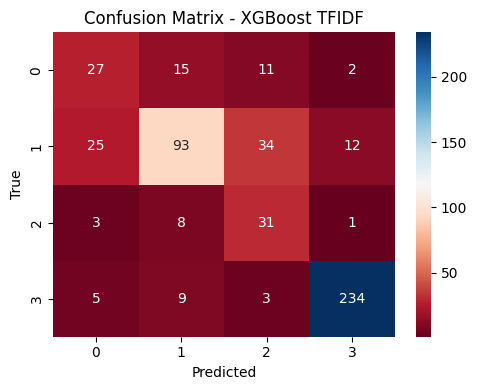

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_tfidf.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts_for_ml)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels_for_ml)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Uni Gram


======== Vectorizer: Unigram ========

Model: Naive Bayes
Test Accuracy: 0.7154
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.42      0.41        55
           1       0.69      0.72      0.71       164
           2       0.40      0.74      0.52        43
           3       0.95      0.77      0.85       251

    accuracy                           0.72       513
   macro avg       0.61      0.66      0.62       513
weighted avg       0.76      0.72      0.73       513



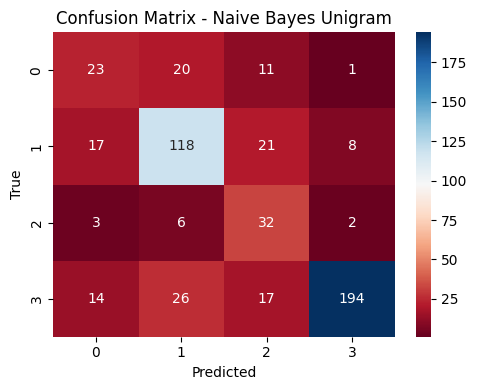


Model: Logistic Regression
Test Accuracy: 0.8168
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55        55
           1       0.79      0.73      0.76       164
           2       0.52      0.74      0.62        43
           3       0.97      0.94      0.96       251

    accuracy                           0.82       513
   macro avg       0.71      0.74      0.72       513
weighted avg       0.83      0.82      0.82       513



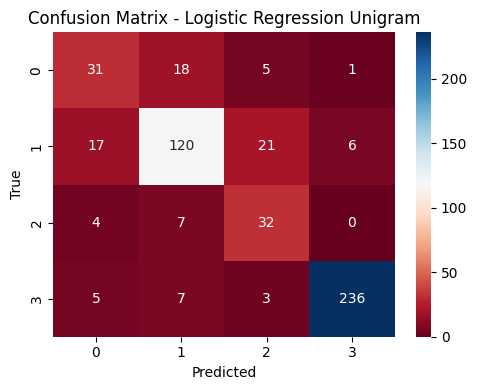


Model: Random Forest
Test Accuracy: 0.7641
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.25      0.36        55
           1       0.67      0.71      0.69       164
           2       0.39      0.49      0.43        43
           3       0.92      0.96      0.94       251

    accuracy                           0.76       513
   macro avg       0.65      0.60      0.60       513
weighted avg       0.76      0.76      0.75       513



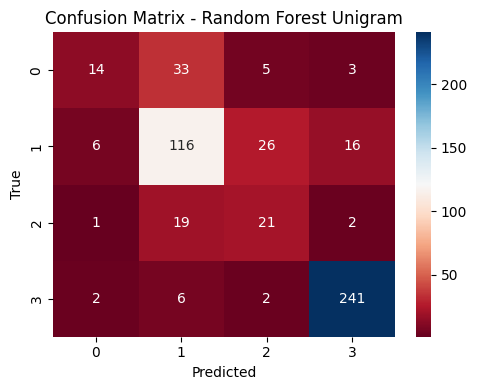


Model: Decision Tree
Test Accuracy: 0.7407
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.27      0.33        55
           1       0.62      0.72      0.67       164
           2       0.41      0.44      0.43        43
           3       0.95      0.91      0.93       251

    accuracy                           0.74       513
   macro avg       0.60      0.59      0.59       513
weighted avg       0.74      0.74      0.74       513



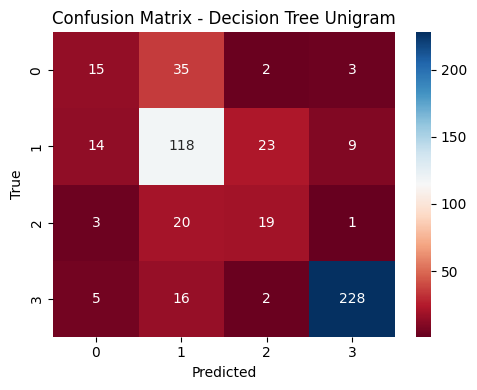


Model: SVM
Test Accuracy: 0.8148
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.58      0.57        55
           1       0.80      0.71      0.75       164
           2       0.54      0.74      0.63        43
           3       0.95      0.94      0.95       251

    accuracy                           0.81       513
   macro avg       0.71      0.75      0.72       513
weighted avg       0.82      0.81      0.82       513



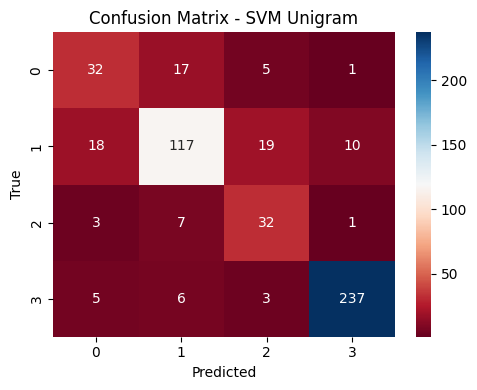


Model: XGBoost
Test Accuracy: 0.7739
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.44      0.46        55
           1       0.80      0.60      0.69       164
           2       0.42      0.81      0.55        43
           3       0.93      0.95      0.94       251

    accuracy                           0.77       513
   macro avg       0.66      0.70      0.66       513
weighted avg       0.80      0.77      0.78       513



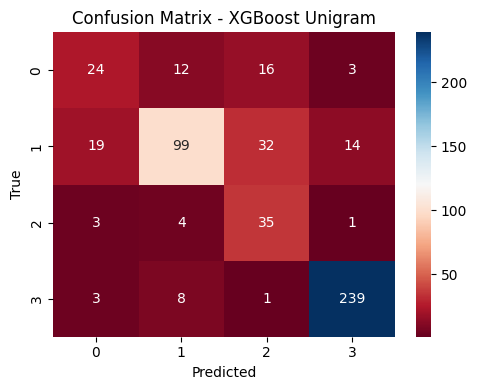

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_unigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts_for_ml)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels_for_ml)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Bi Gram


======== Vectorizer: Bigram ========

Model: Naive Bayes
Test Accuracy: 0.7368
Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.29      0.33        55
           1       0.68      0.77      0.72       164
           2       0.43      0.56      0.48        43
           3       0.92      0.84      0.88       251

    accuracy                           0.74       513
   macro avg       0.60      0.62      0.60       513
weighted avg       0.75      0.74      0.74       513



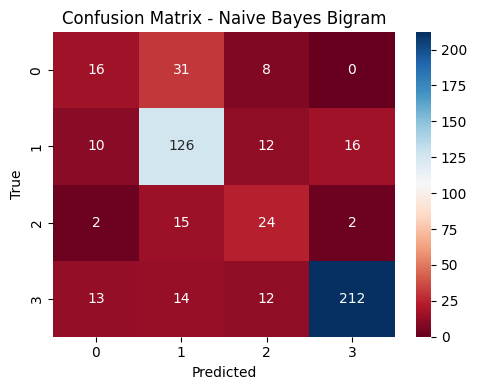


Model: Logistic Regression
Test Accuracy: 0.8382
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.40      0.49        55
           1       0.75      0.82      0.78       164
           2       0.62      0.58      0.60        43
           3       0.96      0.99      0.97       251

    accuracy                           0.84       513
   macro avg       0.74      0.70      0.71       513
weighted avg       0.83      0.84      0.83       513



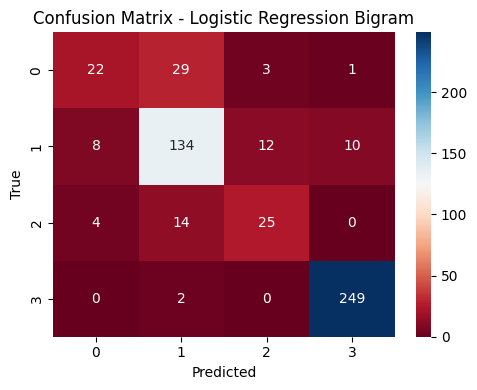


Model: Random Forest
Test Accuracy: 0.7719
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.20      0.30        55
           1       0.67      0.71      0.69       164
           2       0.47      0.42      0.44        43
           3       0.89      1.00      0.94       251

    accuracy                           0.77       513
   macro avg       0.65      0.58      0.59       513
weighted avg       0.75      0.77      0.75       513



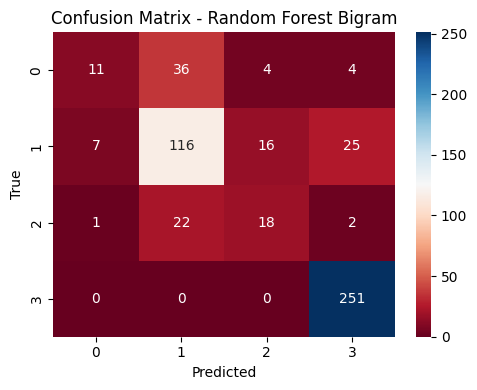


Model: Decision Tree
Test Accuracy: 0.7973
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.16      0.24        55
           1       0.66      0.84      0.74       164
           2       0.52      0.37      0.43        43
           3       0.97      0.98      0.98       251

    accuracy                           0.80       513
   macro avg       0.65      0.59      0.60       513
weighted avg       0.78      0.80      0.78       513



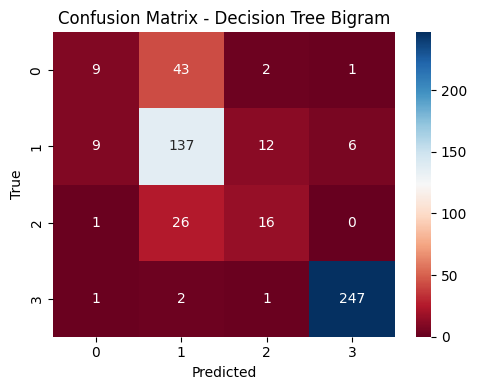


Model: SVM
Test Accuracy: 0.8499
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.38      0.49        55
           1       0.75      0.87      0.80       164
           2       0.69      0.56      0.62        43
           3       0.97      0.99      0.98       251

    accuracy                           0.85       513
   macro avg       0.77      0.70      0.72       513
weighted avg       0.84      0.85      0.84       513



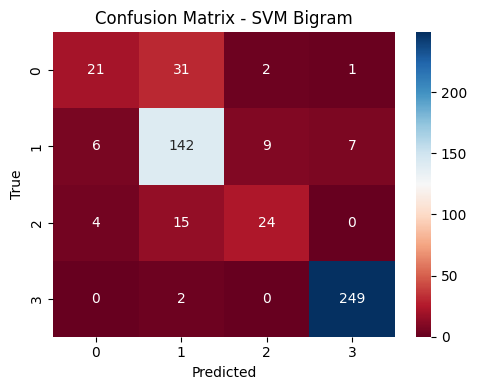


Model: XGBoost
Test Accuracy: 0.7427
Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.69      0.47        55
           1       0.85      0.42      0.56       164
           2       0.37      0.58      0.45        43
           3       0.97      0.99      0.98       251

    accuracy                           0.74       513
   macro avg       0.64      0.67      0.62       513
weighted avg       0.81      0.74      0.75       513



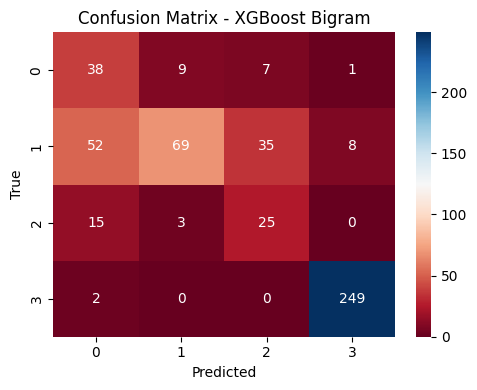

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts_for_ml)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels_for_ml)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Tri Gram


======== Vectorizer: Trigram ========

Model: Naive Bayes
Test Accuracy: 0.7485
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.25      0.33        55
           1       0.76      0.63      0.69       164
           2       0.57      0.49      0.53        43
           3       0.79      0.98      0.88       251

    accuracy                           0.75       513
   macro avg       0.65      0.59      0.60       513
weighted avg       0.73      0.75      0.73       513



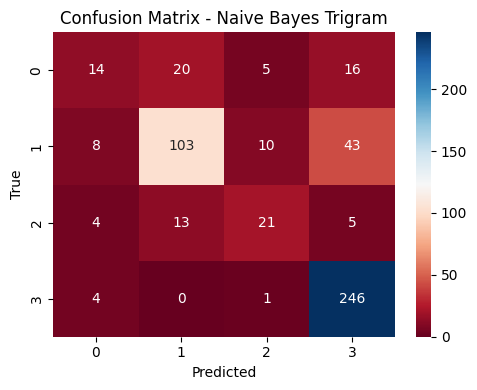


Model: Logistic Regression
Test Accuracy: 0.7466
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.29      0.43        55
           1       0.80      0.57      0.66       164
           2       0.64      0.53      0.58        43
           3       0.73      1.00      0.85       251

    accuracy                           0.75       513
   macro avg       0.75      0.60      0.63       513
weighted avg       0.76      0.75      0.72       513



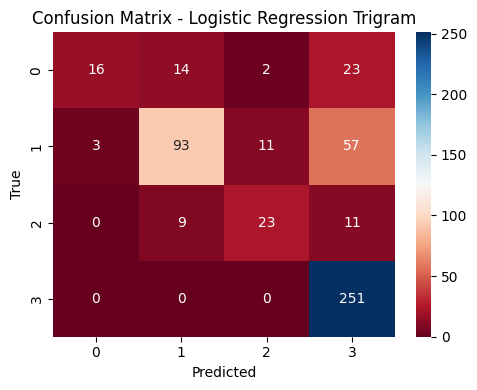


Model: Random Forest
Test Accuracy: 0.6511
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.20      0.32        55
           1       0.82      0.35      0.49       164
           2       0.47      0.33      0.38        43
           3       0.63      1.00      0.77       251

    accuracy                           0.65       513
   macro avg       0.69      0.47      0.49       513
weighted avg       0.70      0.65      0.60       513



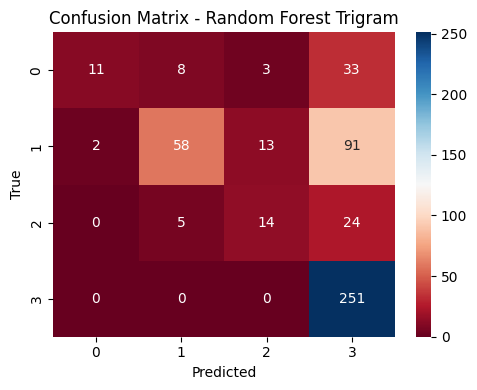


Model: Decision Tree
Test Accuracy: 0.6277
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.15      0.25        55
           1       0.77      0.30      0.44       164
           2       0.57      0.30      0.39        43
           3       0.60      1.00      0.75       251

    accuracy                           0.63       513
   macro avg       0.68      0.44      0.46       513
weighted avg       0.67      0.63      0.57       513



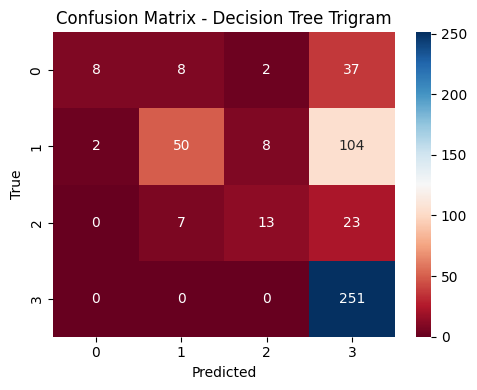


Model: SVM
Test Accuracy: 0.7446
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.33      0.46        55
           1       0.77      0.55      0.65       164
           2       0.65      0.51      0.57        43
           3       0.74      1.00      0.85       251

    accuracy                           0.74       513
   macro avg       0.74      0.60      0.63       513
weighted avg       0.75      0.74      0.72       513



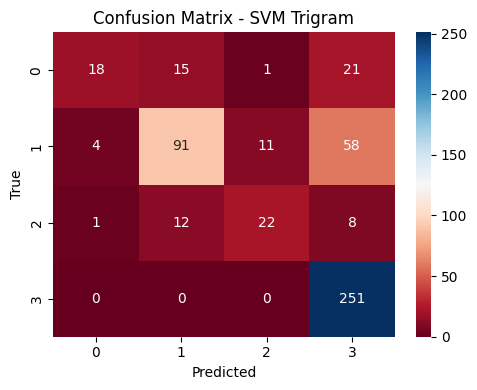


Model: XGBoost
Test Accuracy: 0.6745
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.35      0.41        55
           1       0.85      0.34      0.48       164
           2       0.41      0.49      0.45        43
           3       0.70      1.00      0.82       251

    accuracy                           0.67       513
   macro avg       0.61      0.54      0.54       513
weighted avg       0.70      0.67      0.64       513



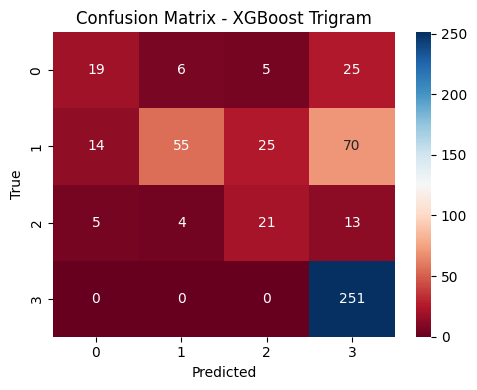

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_trigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts_for_ml)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels_for_ml)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


# **Visual Data Augmentasi**

In [ ]:
display(df.head(2))

,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0


In [ ]:
display(df_aug.head(2))

,stemming,sentiment,label
0,suka sekali slow living,netral,0
2,planning slow living kereta rel listrik transi...,netral,0


In [ ]:
df_new = pd.concat([df, df_aug], ignore_index=True)
display(df_new.head())
df_new.info()

,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0
2,other,slow jam tirzah,3
3,positif,dulu selalu ingin slow living di italy,1
4,positif,celebrating day nonton bareng slow living kaka...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5241 entries, 0 to 5240
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  5241 non-null   object
 1   stemming   5241 non-null   object
 2   label      5241 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 123.0+ KB


/tmp/ipython-input-510124321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


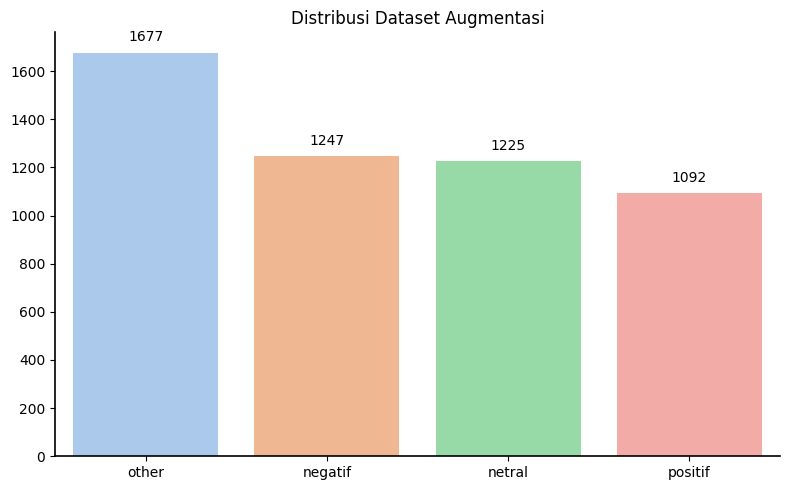

In [ ]:
# Mapping label ke nama sentimen
label_to_sentiment = {0: 'netral', 1: 'positif', 2: 'negatif', 3: 'other'}
df_new['sentiment'] = df_new['label'].map(label_to_sentiment)

# Hitung jumlah per sentimen
label_counts = df_new['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Dataset Augmentasi')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Berikut adalah beberapa kekurangan potensial dari konfigurasi augmentasi menggunakan Synonym Replacement dengan XLM-R dan Sentence-Transformer:

*   **Kualitas Sinonim:** Model masking mungkin menghasilkan sinonim yang kurang relevan atau terdengar tidak alami dalam bahasa Indonesia, terutama untuk konteks spesifik.
*   **Akurasi Semantik:** Filter kesamaan semantik mungkin tidak sempurna menangkap nuansa makna, dan threshold yang terlalu rendah dapat memasukkan pengganti yang mengubah arti kalimat.
*   **Perubahan Makna Tak Sengaja:** Penggantian kata bisa mengubah makna asli kalimat atau membuatnya terdengar janggal, memperkenalkan 'noise' pada data.
*   **Bias Model:** Kualitas augmentasi dipengaruhi oleh data latih model masking; jika tidak representatif, hasilnya bisa bias.
*   **Biaya Komputasi:** Proses ini bisa memakan waktu dan sumber daya, terutama dengan model besar dan banyak variasi.
*   **Stopwords & Istilah Khusus:** Daftar stopwords manual mungkin tidak lengkap, dan istilah domain spesifik bisa terubah secara tidak sengaja.
*   **Duplikasi:** Meskipun ada upaya penghapusan, duplikasi hasil augmentasi masih mungkin terjadi.
*   **Target Augmentasi Tetap:** Menetapkan jumlah target per label secara kaku mungkin tidak ideal untuk semua distribusi data.

Analisis manual terhadap hasil augmentasi diperlukan untuk memastikan kualitas dan menyesuaikan parameter jika perlu.